## CIKs List for DirectEdgar

* We will extract the list of CIKs from Compustat and export list to .CSV file.
  * The .CSV file serves as the input to the query on DirectEdgar's platform. 
  * This ensures the tax rate reconciliation results that we return only relate to the CIKs that appear in the .CSV file. 
* More information about the Query Tool is available on the DirectEdgar blog at the following link: https://directedgar.blog/support/query-tool/.

In [1]:
from pathlib import Path
import pandas as pd

base_path = Path("/Users/anhnguyen/Library/CloudStorage/Box-Box/My Box Notes/Fall 2025/AAE 722 Machine Learning in Applied Economic Analysis/Final Project/Scripts")


input_path = base_path / "../Data/Data Compustat 2011-2025July ETR.dta"
ciks_path = base_path / "../Data/ciks.csv"

# 1. Load Compustat dataset
df = pd.read_stata(input_path)

# 2. Keep fiscal years 2018–2024
df = df[(df["fyear"] >= 2018) & (df["fyear"] <= 2024)]

# 3. Drop observations with missing or zero assets / stock price
df = df[df["at"].notna() & (df["at"] != 0)]
df = df[df["prcc_f"].notna() & (df["prcc_f"] != 0)]

# 4. Keep only CIK column
df = df[["cik"]].copy()

# 5. Drop missing / empty CIKs
df = df[df["cik"].notna() & (df["cik"] != "")]

# 6. Drop duplicate CIKs
df = df.drop_duplicates(subset="cik")

# 7. Rename cik -> CIK
df = df.rename(columns={"cik": "CIK"})

# 8. "Destring" CIK (convert to integer)
df["CIK"] = pd.to_numeric(df["CIK"], errors="raise", downcast="integer")

# 9. Export list to CSV
df.to_csv(ciks_path, index=False)

print(df.dtypes)
print(df.shape)

CIK    int32
dtype: object
(8881, 1)


## Clean DirectEdgar Dataset

* We are comfortable that DirectEdgar is a reliable source.:
  * Of the 8,881 CIKs that we used in our DirectEdgar query, 3,171 did not return any data. 
  * Based on random inspection of 15 unmatched CIKs and coummincating with DirectEdgar, the primary reasons CIKs are not returned in a search are 
    * (i) they belonged to foreign filers (the majority), 
    * (ii) they belonged to investment vehicles, not actual firms, 
    * (iii) the XBRL tags did not align with the HTML labels in the filing which prevented DirectEdgar from assigning values to labels, 
    * (iv) the CIK was a publicly traded subsidiary which prevents DiectEdgar from cleanly assigning data, or 
    * (v) the CIK was backfiled by Compustat (following a merger, etc.) and does not match CIKs attached to filings on the SEC website. 
  * In total, only 1 of the CIKs randomly sampled, fell outside of category (i) and (ii).

* ETR columns definitions: https://directedgar.blog/support/effective-tax-rate-reconciliation/?keywords=effective+tax.

In [2]:
base_path = Path("/Users/anhnguyen/Library/CloudStorage/Box-Box/My Box Notes/Fall 2025/AAE 722 Machine Learning in Applied Economic Analysis/Final Project/Scripts")

taxrecs_path = base_path / "../Data/tax_recs_2018_2025.csv"

# Load DirectEdgar data
df_de = pd.read_csv(taxrecs_path, dtype=str)

print(df_de.dtypes)
print(df_de.shape)



CIK                       object
ACCESSION                 object
TABLE_NO                  object
ROW_N                     object
unitref                   object
decimals                  object
scale                     object
name                      object
orig_row_label            object
CURRENTYEAR               object
CURRENTYEAR_START_DATE    object
CURRENTYEAR_END_DATE      object
TABLE_TYPE                object
ROW_TYPE                  object
FLAG                      object
SOURCE                    object
dtype: object
(286862, 16)


In [3]:
# Make sure key numeric columns are numeric where needed
df_de["CIK"] = pd.to_numeric(df_de["CIK"], errors="coerce")
df_de["ROW_N"] = pd.to_numeric(df_de["ROW_N"], errors="coerce")


In [4]:
# Drop bad data: drop if flag != ""
if "FLAG" in df_de.columns:
    df_de = df_de[df_de["FLAG"].isna() | (df_de["FLAG"] == "")]

# Reformat fiscal year end: date_v = date(currentyear_end_date, "YMD")
df_de["date_v"] = pd.to_datetime(df_de["CURRENTYEAR_END_DATE"], errors="coerce")

# Align datadate with month ends (literal Stata logic)
df_de["month_dd"] = df_de["date_v"].dt.month
df_de["day_dd"] = df_de["date_v"].dt.day
df_de["year_dd"] = df_de["date_v"].dt.year

# month_r
df_de["month_r"] = df_de["month_dd"]
mask_prev_month = (df_de["day_dd"] < 15) & (df_de["month_dd"] > 1)
df_de.loc[mask_prev_month, "month_r"] = df_de.loc[mask_prev_month, "month_dd"] - 1
mask_jan_prev_year = (df_de["day_dd"] < 15) & (df_de["month_dd"] == 1)
df_de.loc[mask_jan_prev_year, "month_r"] = 12

# day_r
df_de["day_r"] = pd.NA
df_de.loc[df_de["month_r"] == 1, "day_r"] = 31
df_de.loc[
    (df_de["month_r"] == 2) & ~df_de["year_dd"].isin([2020, 2024]),
    "day_r"
] = 28
df_de.loc[
    (df_de["month_r"] == 2) & df_de["year_dd"].isin([2020, 2024]),
    "day_r"
] = 29
df_de.loc[df_de["month_r"] == 3, "day_r"] = 31
df_de.loc[df_de["month_r"] == 4, "day_r"] = 30
df_de.loc[df_de["month_r"] == 5, "day_r"] = 31
df_de.loc[df_de["month_r"] == 6, "day_r"] = 30
df_de.loc[df_de["month_r"] == 7, "day_r"] = 31
df_de.loc[df_de["month_r"] == 8, "day_r"] = 31
df_de.loc[df_de["month_r"] == 9, "day_r"] = 30
df_de.loc[df_de["month_r"] == 10, "day_r"] = 31
df_de.loc[df_de["month_r"] == 11, "day_r"] = 30
df_de.loc[df_de["month_r"] == 12, "day_r"] = 31

# year_r
df_de["year_r"] = df_de["year_dd"]
mask_year_minus_1 = (df_de["month_dd"] == 1) & (df_de["day_dd"] < 15)
df_de.loc[mask_year_minus_1, "year_r"] = df_de.loc[mask_year_minus_1, "year_dd"] - 1

# mdy = string(month_r, "%02.0f") + string(day_r, "%02.0f") + string(year_r)
df_de["month_r_str"] = df_de["month_r"].astype("Int64").astype(str).str.zfill(2)
df_de["day_r_str"] = df_de["day_r"].astype("Int64").astype(str).str.zfill(2)
df_de["year_r_str"] = df_de["year_r"].astype("Int64").astype(str)
df_de["mdy"] = df_de["month_r_str"] + df_de["day_r_str"] + df_de["year_r_str"]

# datadate = date(mdy, "MDY")
df_de["datadate"] = pd.to_datetime(df_de["mdy"], format="%m%d%Y", errors="coerce")
print(df_de[["CURRENTYEAR_END_DATE", "date_v", "datadate"]].head(2))

# Drop intermediate date variables: drop date_v *_dd *_r mdy
df_de = df_de.drop(
    columns=[
        "date_v",
        "month_dd", "day_dd", "year_dd",
        "month_r", "day_r", "year_r",
        "month_r_str", "day_r_str", "year_r_str",
        "mdy"
    ]
)

# print datadate dtypes and shape
print(df_de["datadate"].dtypes)


  CURRENTYEAR_END_DATE     date_v   datadate
0           2022-10-31 2022-10-31 2022-10-31
1           2022-10-31 2022-10-31 2022-10-31
datetime64[ns]


## Opacity = Combination of D1, D2, and D3

* We will use K-means clustering (unsupervised non-parametric method)
  * Unsupervised because we dont really have a pre-defined variable for opacity -> this is a variable that we create using the data
  * Non-parametric because we will let the data speak instead of giving the weights to each dimensions
* We will use 3 dimensions to create this Opacity variable:
  * D1 = the proportion of other reconciling items (higher = more opaque)
  * D2 = an indicator whether a firm uses one unit to disclose ETR reconciling items (higher = more opaque)
  * D3 = aggregation level, calculating as the ratio of the number of line items over total lagged assets multipled by negative 1 (higher = more opaque)

### Dedupe phase 1

* Most duplicates are because the firm presented the reconciliation in multiple places in the filing. 
* Because we are interested in disaggregation, we will keep the maximum number of line items by dropping duplicate line items (as opposed to duplicate tables). 
* This way, if one table has more information, we continue to retain that information.

In [5]:
# Drop duplicates based on orig_row_label within (CIK, datadate)
df_de = df_de.sort_values(["CIK", "datadate", "orig_row_label"])

# N = _N (total rows in each group)
df_de["N"] = df_de.groupby(["CIK", "datadate", "orig_row_label"])["CIK"].transform("size")

# n = _n (row index inside group, starting at 1)
df_de["n"] = df_de.groupby(["CIK", "datadate", "orig_row_label"]).cumcount() + 1

# Drop if N > 1 & n != 1 (keep only the first occurrence)
df_de = df_de[~((df_de["N"] > 1) & (df_de["n"] != 1))].copy()

# Drop helper columns
df_de = df_de.drop(columns=["N", "n"])

print(df_de.shape)

(256501, 17)


* Duplicates due to incorrect row labelling by DirectEdgar  -> we delete these
* Duplicates due to incorrect row numbering by DirectEdgar -> we want to keep these duplicates

In [6]:
import pandas as pd

# 1. Clean currentyear values 
df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].astype(str).str.strip()

df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].replace({
    "": ".",
    "-1,035,815": "-1035815",
    ".0": "0",
    "-833,505": "-833505",
    "1,524,637": "1524637",
    "3,519,246": "3519246",
    "44,605,000": "44605000"
})

df_de["CURRENTYEAR"] = df_de["CURRENTYEAR"].replace(".", pd.NA)

# destring currentyear, replace
df_de["CURRENTYEAR"] = pd.to_numeric(df_de["CURRENTYEAR"], errors="coerce")

# 2. Recompute N and max_n in case they were dropped earlier
df_de = df_de.sort_values(["CIK", "datadate", "ROW_N"])

df_de["N"] = df_de.groupby(["CIK", "datadate", "ROW_N"])["CIK"].transform("size")
df_de["max_n"] = df_de.groupby(["CIK", "datadate"])["N"].transform("max")

# 3. val_diff = currentyear - currentyear[_n-1] within (CIK, datadate, row_n)
df_de["val_diff"] = df_de.groupby(["CIK", "datadate", "ROW_N"])["CURRENTYEAR"].diff()

# 4. Drop if max_n > 1 & val_diff == 0  (true duplicates with same numeric value)
mask_drop = (df_de["max_n"] > 1) & (df_de["val_diff"] == 0)
df_de = df_de[~mask_drop].copy()

# 5. Drop helper variables
df_de = df_de.drop(columns=["N", "max_n", "val_diff"])

print(df_de.shape)


(256486, 17)


### Remove statutory rates / provision rates

* Drop any rows that provide 21% tax rate or provision for income taxes
  * first, flag any rows identified with 'u.s. statutory rate' and 'provision for income taxes'
  * inspect what we are catching
  * then drop those rows out of our sample
* Reason why we are doing this: Displaying statutory tax rates or provision for income taxes neither give firms more or less power in hiding anything nor allows us to inspect the disaggregation/opacity level of firms' disclosure behavior.

In [7]:
import pandas as pd
import re

# Standardize orig_row_label to lowercase for pattern matching
label = df_de["orig_row_label"].fillna("").str.lower()

# 1. Core "statutory + tax" context
mask_statutory = label.str.contains("statutory")

mask_tax_context = (
    label.str.contains("tax") |
    label.str.contains("income tax") |
    label.str.contains("income taxes") |
    label.str.contains("tax rate") |
    label.str.contains("tax expense") |
    label.str.contains("tax benefit") |
    label.str.contains("expected statutory tax") |
    label.str.contains("federal statutory income tax") |
    label.str.contains("federal statutory tax") |
    label.str.contains("statutory federal tax") |
    label.str.contains("statutory federal rate") | 
    label.str.contains("statutory federal income tax") |       
    label.str.contains("statutory federal income rate") |   
    label.str.contains("statutory federal income tax rate") | 
    label.str.contains("statutory rate") |  
    label.str.contains("statutory us rate") |  
    label.str.contains("statutory united states rate") | 
    label.str.contains("statutory u\.s\. rate") |  
    label.str.contains("statutory u\.s\. tax rate")  |
    label.str.contains("statutory u\.s\. income tax rate")  |
    label.str.contains("statutory u\.s\. federal rate")  |
    label.str.contains("statutory us federal rate")  |
    label.str.contains("us statutory federal rate") |          
    label.str.contains("u\.s\. statutory federal rate") |
    label.str.contains("united states statutory federal rate") 
)

mask_include = mask_statutory & mask_tax_context

# 2. Exclude non-US / non-federal statutory rows
mask_exclude = (
    label.str.contains("foreign") |
    label.str.contains("international") |
    label.str.contains("non-us") |
    label.str.contains("non u.s.") |
    label.str.contains(r"\bstate\b") | 
    label.str.contains("provincial") |
    label.str.contains("local") 
)

df_de["statutory_flag"] = (mask_include & ~mask_exclude).astype(int)

# Keep only rows where statutory_flag == 0
df_de = df_de[df_de["statutory_flag"] == 0].copy()

# Check
df_de[df_de["orig_row_label"].str.contains("statutory", case=False, na=False)][
    ["CIK", "datadate", "orig_row_label","CURRENTYEAR","TABLE_TYPE","statutory_flag"]
].head(10)

,CIK,datadate,orig_row_label,CURRENTYEAR,TABLE_TYPE,statutory_flag
48386,1961,2021-12-31,Income tax computed at the state statutory rate,5.0,PERCENT,0
25968,1961,2022-12-31,Income tax computed at the state statutory rate,5.0,PERCENT,0
214255,1961,2023-12-31,Income tax computed at the state statutory rate,5.0,PERCENT,0
277076,1961,2024-12-31,Income tax computed at the state statutory rate,5.0,PERCENT,0
187102,2178,2018-12-31,Federal statutory depletion,0.0,DOLLARS,0
184397,2178,2019-12-31,Federal statutory depletion,0.0,DOLLARS,0
115998,7084,2018-12-31,Foreign earnings taxed at rates other than the...,-1.5,PERCENT,0
91656,7084,2019-12-31,Foreign earnings taxed at rates other than the...,-2.2,PERCENT,0
188488,7084,2020-12-31,Foreign earnings taxed at rates other than the...,-4.5,PERCENT,0
188079,7084,2021-12-31,Foreign earnings taxed at rates other than the...,-3.9,PERCENT,0


### D1: the proportion of 'other' reconciling items

* First create the other_flag column, in which other_flag = 1 if ‘other’ or ‘others’ are identified. Otherwise, it’s 0. 
  * case=False to ignore uppercase/lowercase differences
  * na=False to treat NaN as False
  * regex=True to interpret patterns as regular expressions

In [8]:
import pandas as pd
import re

# Lists for include/exclude patterns
pattern_include_list = [
    r'other',
    r'other permanent',
    r'other items',
    r'other \d+',
    r'other[_ ]'
]

pattern_exclude_list = [
    r'other\s+financial\s+terms'
]

# Build regex patterns
pattern_include = "(" + "|".join(pattern_include_list) + ")"
pattern_exclude = "(" + "|".join(pattern_exclude_list) + ")"

# Create index column
df_de['other_flag'] = (
    df_de['orig_row_label'].str.contains(pattern_include, case=False, na=False, regex=True) &
    ~df_de['orig_row_label'].str.contains(pattern_exclude, case=False, na=False, regex=True)
).astype(int)

# Double check
df_de[['CIK', 'datadate', 'orig_row_label', 'other_flag', 'CURRENTYEAR', 'TABLE_TYPE']].head(6)



/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_83949/3399062325.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_de['orig_row_label'].str.contains(pattern_include, case=False, na=False, regex=True) &
/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_83949/3399062325.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_de['orig_row_label'].str.contains(pattern_exclude, case=False, na=False, regex=True)


,CIK,datadate,orig_row_label,other_flag,CURRENTYEAR,TABLE_TYPE
143766,1750,2018-05-31,Deferred tax re-measurement from the Tax Refor...,0,-14100000.0,DOLLARS
143767,1750,2018-05-31,Excess tax benefits from stock-based compensation,0,-2900000.0,DOLLARS
143768,1750,2018-05-31,State net operating losses,0,1300000.0,DOLLARS
143769,1750,2018-05-31,Change in valuation allowance for state deferr...,0,-3400000.0,DOLLARS
143770,1750,2018-05-31,Other,1,100000.0,DOLLARS
143771,1750,2018-05-31,Provision for income tax,0,3500000.0,DOLLARS


* Create provision_flag column
  * case=False to ignore uppercase/lowercase differences
  * na=False to treat NaN as False
  * regex=True to interpret patterns as regular expressions

In [9]:
import pandas as pd
import re

# Lists for include/exclude patterns
pattern_include_list_provision = [
    r'provision',
    r'provision \d+',
    r'provision[_ ]'
]

pattern_exclude_list_provision = [
    r'provision\s+state\s+taxes'
]

# Build regex patterns
pattern_include_provision = "(" + "|".join(pattern_include_list_provision) + ")"
pattern_exclude_provision = "(" + "|".join(pattern_exclude_list_provision) + ")"

# Create provision_flag column


df_de['provision_flag'] = (
    df_de['orig_row_label'].str.contains(pattern_include_provision, case=False, na=False, regex=True) &
    ~df_de['orig_row_label'].str.contains(pattern_exclude_provision, case=False, na=False, regex=True)
).astype(int)

df_de[['CIK', 'datadate', 'orig_row_label', 'provision_flag', 'CURRENTYEAR', 'TABLE_TYPE']].head(6)


/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_83949/670274861.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_de['orig_row_label'].str.contains(pattern_include_provision, case=False, na=False, regex=True) &
/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_83949/670274861.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_de['orig_row_label'].str.contains(pattern_exclude_provision, case=False, na=False, regex=True)


,CIK,datadate,orig_row_label,provision_flag,CURRENTYEAR,TABLE_TYPE
143766,1750,2018-05-31,Deferred tax re-measurement from the Tax Refor...,0,-14100000.0,DOLLARS
143767,1750,2018-05-31,Excess tax benefits from stock-based compensation,0,-2900000.0,DOLLARS
143768,1750,2018-05-31,State net operating losses,0,1300000.0,DOLLARS
143769,1750,2018-05-31,Change in valuation allowance for state deferr...,0,-3400000.0,DOLLARS
143770,1750,2018-05-31,Other,0,100000.0,DOLLARS
143771,1750,2018-05-31,Provision for income tax,1,3500000.0,DOLLARS


* Create other_share column 
  * This is our D1: the proportion of 'other' reconcling item
    * If any of those are TABLE_TYPE == "PERCENT" → use the percentage as other_share
    * Else, if only DOLLARS:
      * other_amt = sum of abs(CURRENTYEAR_NUM) for index == 1 and TABLE_TYPE == "DOLLARS".
      * total_amt = sum of abs(CURRENTYEAR_NUM) for all DOLLARS rows in that firm–date (except for the one with provision flag ==1)
      * other_share = other_amt / total_amt, other_source = "dollar".
    * If no usable numbers → other_share = NaN.

In [10]:
import numpy as np

df_de["TABLE_TYPE"] = df_de["TABLE_TYPE"].str.upper().str.strip()

df_de = df_de.dropna(subset=["CURRENTYEAR"])

group_cols = ["CIK", "datadate"]

def compute_other_metrics(g):
    g_other = g[g["other_flag"] == 1]
    if g_other.empty:
        return pd.Series({"other_share": np.nan, "other_source": "none"})

    g_other_pct = g_other[g_other["TABLE_TYPE"] == "PERCENT"]
    if not g_other_pct.empty:
        other_pct = g_other_pct["CURRENTYEAR"].abs().sum()
        return pd.Series({"other_share": other_pct, "other_source": "percent"})

    g_other_dol = g_other[g_other["TABLE_TYPE"] == "DOLLARS"]
    g_dol = g[g["TABLE_TYPE"] == "DOLLARS"]

    if not g_other_dol.empty and not g_dol.empty:
        other_amt = g_other_dol["CURRENTYEAR"].abs().sum()

        if "provision_flag" in g_dol.columns:
            g_dol_total = g_dol[g_dol["provision_flag"] != 1]
        else:
            g_dol_total = g_dol

        total_amt = g_dol_total["CURRENTYEAR"].abs().sum()

        if total_amt == 0 or pd.isna(total_amt):
            share = np.nan
        else:
            share = other_amt / total_amt

        return pd.Series({"other_share": share, "other_source": "dollar"})

    return pd.Series({"other_share": np.nan, "other_source": "no_amount"})

other_metrics = df_de.groupby(group_cols).apply(compute_other_metrics).reset_index()

df_de = df_de.merge(other_metrics, on=group_cols, how="left")

df_de = df_de.dropna(subset=["other_share"])


/var/folders/k2/t51qvyjx7nq1655869hcs4nc0000gn/T/ipykernel_83949/2709478508.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  other_metrics = df_de.groupby(group_cols).apply(compute_other_metrics).reset_index()


In [11]:
# Quick diagnostic
df_de[df_de["other_share"] < 0][["CIK","datadate","orig_row_label","other_share"]].head(20)


,CIK,datadate,orig_row_label,other_share


In [12]:
# Quick checks
df_de[(df_de["CIK"] == 1750) & (df_de["datadate"] == "2018-05-31")][
    ["CIK", "datadate", "orig_row_label", "CURRENTYEAR", "other_flag", "other_share", "other_source"]
]

,CIK,datadate,orig_row_label,CURRENTYEAR,other_flag,other_share,other_source
0,1750,2018-05-31,Deferred tax re-measurement from the Tax Refor...,-14100000.0,0,0.004587,dollar
1,1750,2018-05-31,Excess tax benefits from stock-based compensation,-2900000.0,0,0.004587,dollar
2,1750,2018-05-31,State net operating losses,1300000.0,0,0.004587,dollar
3,1750,2018-05-31,Change in valuation allowance for state deferr...,-3400000.0,0,0.004587,dollar
4,1750,2018-05-31,Other,100000.0,1,0.004587,dollar
5,1750,2018-05-31,Provision for income tax,3500000.0,0,0.004587,dollar


### D2: whether a firm discloses in only one unit

In [13]:
# Count rows per (CIK, datadate, table_type)
df_de["table_n"] = df_de.groupby(["CIK", "datadate", "TABLE_TYPE"])["CIK"].transform("size")

# Count rows per (CIK, datadate)
df_de["firm_n"] = df_de.groupby(["CIK", "datadate"])["CIK"].transform("size")

# multi_rec = 1 if firm has multiple reconciliations (i.e., uses both units)
df_de["multi_rec"] = (df_de["table_n"] != df_de["firm_n"]).astype(int)

# Opacity-style indicators at the firm–date level
df_de["disclose_both_units"] = df_de["multi_rec"]           # 1 = both dollar & percent, 0 = only one
df_de["disclose_one_unit"] = (df_de["multi_rec"] == 0).astype(int)  # 1 = only one unit, 0 = both

# Drop intermediate counting columns
df_de = df_de.drop(columns=["table_n", "firm_n", "multi_rec"])

# Preview new indicators
df_de.head(6)



,CIK,ACCESSION,TABLE_NO,ROW_N,unitref,decimals,scale,name,orig_row_label,CURRENTYEAR,...,FLAG,SOURCE,datadate,statutory_flag,other_flag,provision_flag,other_share,other_source,disclose_both_units,disclose_one_unit
0,1750,0001047469-18-004978,55,2,Unit1,-5,NaN,IncomeTaxReconciliationChangeInEnactedTaxRate,Deferred tax re-measurement from the Tax Refor...,-14100000.0,...,NaN,HTML,2018-05-31,0,0,0,0.004587,dollar,0,1
1,1750,0001047469-18-004978,55,3,Unit1,-5,NaN,EffectiveIncomeTaxRateReconciliationExcessTaxB...,Excess tax benefits from stock-based compensation,-2900000.0,...,NaN,HTML,2018-05-31,0,0,0,0.004587,dollar,0,1
2,1750,0001047469-18-004978,55,4,Unit1,-5,NaN,EffectiveIncomeTaxRateReconciliationNetOperati...,State net operating losses,1300000.0,...,NaN,HTML,2018-05-31,0,0,0,0.004587,dollar,0,1
3,1750,0001047469-18-004978,55,5,Unit1,-5,NaN,IncomeTaxReconciliationChangeInDeferredTaxAsse...,Change in valuation allowance for state deferr...,-3400000.0,...,NaN,HTML,2018-05-31,0,0,0,0.004587,dollar,0,1
4,1750,0001047469-18-004978,55,8,Unit1,-5,NaN,IncomeTaxReconciliationOtherAdjustments,Other,100000.0,...,NaN,HTML,2018-05-31,0,1,0,0.004587,dollar,0,1
5,1750,0001047469-18-004978,55,9,Unit1,-5,NaN,IncomeTaxExpenseBenefitIntraperiodTaxAllocation,Provision for income tax,3500000.0,...,NaN,HTML,2018-05-31,0,0,1,0.004587,dollar,0,1


### Dedupe phase #2

* Remove duplicates because firms use both units 

In [14]:
print(df_de["TABLE_TYPE"].unique())

# mask_firm_has_both = disclose_both_units == 1
mask_both = df_de["disclose_both_units"] == 1

# Drop the PERCENT row only when both units exist
df_de = df_de[~(mask_both & (df_de["TABLE_TYPE"] == "PERCENT"))]

# Double check
remaining_percent = df_de[
    (df_de["disclose_both_units"] == 1) &
    (df_de["TABLE_TYPE"] == "PERCENT")
]

print(remaining_percent.shape)

print(df_de.shape)

['DOLLARS' 'PERCENT']
(0, 24)
(200919, 24)


* Investigate the rest of duplicates
  * Duplicates due to incorrect row numbering by DirectEdgar -> we want to keep these duplicates
  * Moving to dimension #3 

In [15]:
dupes = df_de.duplicated(subset=["CIK", "datadate", "ROW_N"] ).value_counts()
print(dupes)

dups_detail = df_de[df_de.duplicated(
    subset=["CIK", "datadate", "ROW_N"], keep=False
)].sort_values(["CIK", "datadate", "ROW_N"])

dups_detail.head(5)

False    200885
True         34
Name: count, dtype: int64


,CIK,ACCESSION,TABLE_NO,ROW_N,unitref,decimals,scale,name,orig_row_label,CURRENTYEAR,...,FLAG,SOURCE,datadate,statutory_flag,other_flag,provision_flag,other_share,other_source,disclose_both_units,disclose_one_unit
24210,99780,0000099780-23-000013,78,4,number,3,-2,NaN,Foreign branch taxes,2.1,...,NaN,IXBRL,2022-12-31,0,0,0,0.8,percent,0,1
24211,99780,0000099780-23-000013,78,4,number,3,-2,NaN,State taxes,1.7,...,NaN,IXBRL,2022-12-31,0,0,0,0.8,percent,0,1
55783,855658,0001437749-21-004238,94,10,Pure,0,-2,lscc:EffectiveIncomeTaxRateReconciliationForei...,Foreign dividends,15.0,...,NaN,IXBRL,2019-12-31,0,0,0,9.0,percent,0,1
55784,855658,0000855658-20-000025,77,10,ratio,2,NaN,EffectiveIncomeTaxRateReconciliationOtherRecon...,Other permanent,6.0,...,NaN,HTML,2019-12-31,0,1,0,9.0,percent,0,1
55785,855658,0001437749-21-004238,94,12,Pure,2,-2,us-gaap:EffectiveIncomeTaxRateReconciliationOt...,162(m) executive compensation limitation,13.0,...,NaN,IXBRL,2019-12-31,0,0,0,9.0,percent,0,1


### D3: Aggregation level

* First, create number of line items in reconciliation
* Then create the disaggregation level calculated as the ratio of # of line items over total lagged assets
* Then create aggregation level by multiple disaggregation level by negative 1 - so that the higher means more opaque in etr disclosure


In [31]:
import pandas as pd

# Load dataset with lagged assets
compustat_path = base_path / "../Data/priorbalancedpanel.dta"
df_comp = pd.read_stata(compustat_path)

# Keep only relevant columns
df_comp = df_comp[["cik", "datadate", "lag_at"]].copy()
df_comp = df_comp.rename(columns={"cik":"CIK"})

# drop rows with missing lag_at
df_comp = df_comp[df_comp["lag_at"].notna()].copy()

# Ensure key columns are correct types
df_comp["CIK"] = pd.to_numeric(df_comp["CIK"], errors="coerce")
df_comp["datadate"] = pd.to_datetime(df_comp["datadate"], errors="coerce")

df_de["CIK"] = pd.to_numeric(df_de["CIK"], errors="coerce")

# Merge lagged assets into DirectEdgar dataset
df_merge = df_de.merge(df_comp, on=["CIK","datadate"], how="left")

# Compute etrrec_lines and disaggregation_level
df_merge["etrrec_lines"] = df_merge.groupby(["CIK","datadate"])["orig_row_label"].transform("size")
df_merge["disaggregation_level"] = df_merge["etrrec_lines"] / df_merge["lag_at"]
df_merge = df_merge[~df_merge["disaggregation_level"].isna()].copy()

# Compute aggregation_level as negative disaggregation_level
df_merge["aggregation_level"] = -1 * df_merge["disaggregation_level"]

print(df_merge[["CIK","datadate","lag_at","etrrec_lines","disaggregation_level","aggregation_level"]].head(10))


      CIK   datadate  lag_at  etrrec_lines  disaggregation_level  \
183  2488 2018-12-31  3540.0             6              0.001695   
184  2488 2018-12-31  3540.0             6              0.001695   
185  2488 2018-12-31  3540.0             6              0.001695   
186  2488 2018-12-31  3540.0             6              0.001695   
187  2488 2018-12-31  3540.0             6              0.001695   
188  2488 2018-12-31  3540.0             6              0.001695   
189  2488 2020-12-31  6028.0             9              0.001493   
190  2488 2020-12-31  6028.0             9              0.001493   
191  2488 2020-12-31  6028.0             9              0.001493   
192  2488 2020-12-31  6028.0             9              0.001493   

     aggregation_level  
183          -0.001695  
184          -0.001695  
185          -0.001695  
186          -0.001695  
187          -0.001695  
188          -0.001695  
189          -0.001493  
190          -0.001493  
191          -0.001493  
1

In [29]:
# Statistics
print(df_merge["aggregation_level"].describe())

#print the firm with the min aggregation level
min_agg_row = df_merge.loc[df_merge["aggregation_level"].idxmin()]
print(min_agg_row[["CIK","datadate","lag_at","etrrec_lines","disaggregation_level","aggregation_level"]])

count    83809.000000
mean        -0.024407
std          0.113467
min        -14.705883
25%         -0.017902
50%         -0.006229
75%         -0.001900
max         -0.000013
Name: aggregation_level, dtype: float64
CIK                                 1766140
datadate                2021-12-31 00:00:00
lag_at                                0.204
etrrec_lines                              3
disaggregation_level              14.705883
aggregation_level                -14.705883
Name: 181958, dtype: object


### Select final columns

In [32]:
# Select final columns
cols = ["CIK","datadate","aggregation_level","other_share","disclose_one_unit"]
df_agg = df_merge[cols].drop_duplicates()

df_agg.head(6)



,CIK,datadate,aggregation_level,other_share,disclose_one_unit
183,2488,2018-12-31,-0.001695,0.018182,1
189,2488,2020-12-31,-0.001493,0.004003,1
198,2488,2021-12-31,-0.001116,0.020408,1
208,2488,2022-12-31,-0.000725,0.160757,1
217,2488,2023-12-31,-0.000118,0.253119,1
225,2488,2024-12-31,-0.000147,0.101530,1


In [33]:
df_agg[["aggregation_level", "other_share", "disclose_one_unit"]].describe()

,aggregation_level,other_share,disclose_one_unit
count,8722.000000,8722.000000,8722.000000
mean,-0.027549,1.484072,0.985668
std,0.176802,20.293761,0.118860
min,-14.705883,0.000000,0.000000
25%,-0.018740,0.015243,1.000000
50%,-0.006034,0.100000,1.000000
75%,-0.001792,0.800000,1.000000
max,-0.000013,1761.600000,1.000000


In [34]:
print(df_agg.shape)
print(df_agg.dtypes)


(8722, 5)
CIK                           int64
datadate             datetime64[ns]
aggregation_level           float64
other_share                 float64
disclose_one_unit             int64
dtype: object


### K-means Clustering

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
import numpy as np

# drop warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# keep rows with required fields
df_k = df_agg.dropna(subset=["aggregation_level", "other_share", "disclose_one_unit"]).copy()

# winsorize; winsorize returns a masked array so grab .data
df_k["agg_w"] = winsorize(df_k["aggregation_level"], limits=[0.01, 0.01]).data
df_k["other_w"] = winsorize(df_k["other_share"], limits=[0.01, 0.01]).data

# Ensure agg_w won't produce invalid values for log1p (log1p(x) requires x > -1).
# Clip very large negative values to a safe lower bound.
df_k["agg_w"] = df_k["agg_w"].clip(lower=-0.999)

# other_w should be non-negative for log1p; clip any tiny negative numerical noise to zero
df_k["other_w"] = df_k["other_w"].clip(lower=0.0)

# Apply transforms: use signed log for aggregation (preserve sign), log1p for other
df_k["agg_log"] = np.sign(df_k["agg_w"]) * np.log1p(np.abs(df_k["agg_w"]))
df_k["other_log"] = np.log1p(df_k["other_w"])

# unit as numeric
df_k["unit"] = df_k["disclose_one_unit"].astype(float)

# print stats of transformed variables
print(df_k[["agg_log", "other_log", "unit"]].describe())


           agg_log    other_log         unit
count  8722.000000  8722.000000  8722.000000
mean     -0.021669     0.394433     0.985668
std       0.043304     0.600383     0.118860
min      -0.257885     0.000000     0.000000
25%      -0.018567     0.015128     1.000000
50%      -0.006016     0.095310     1.000000
75%      -0.001791     0.587787     1.000000
max      -0.000051     2.970414     1.000000


In [36]:

# Features to use
features = ["agg_log", "other_log", "unit"]

# Replace infinities and very large values with NaN, then drop those rows
df_k[features] = df_k[features].replace([np.inf, -np.inf], np.nan)
df_k = df_k.dropna(subset=features).copy()

# Detect and drop constant columns (StandardScaler would divide by zero otherwise)
X = df_k[features].astype(float)
non_constant_cols = [c for c in X.columns if X[c].nunique() > 1]

if len(non_constant_cols) == 0:
	raise ValueError("All selected features are constant; cannot cluster.")
features_to_use = non_constant_cols

# Scale only the non-constant features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_k[features_to_use])

# Fit k-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=30)
df_k["opacity_cluster"] = kmeans.fit_predict(X_scaled)

* Check statistics

In [37]:
df_opacity = df_agg.merge(
    df_k[["CIK", "datadate", "opacity_cluster"]],
    on=["CIK", "datadate"],
    how="left"
)

print(df_opacity.shape)
print(df_opacity["opacity_cluster"].value_counts(dropna=False))
df_k.groupby("opacity_cluster")[["aggregation_level", "other_share", "disclose_one_unit"]].mean()



(8722, 6)
opacity_cluster
0    8025
1     572
2     125
Name: count, dtype: int64


,aggregation_level,other_share,disclose_one_unit
opacity_cluster,,,
0,-0.011868,1.524759,1.0
1,-0.248730,1.176643,1.0
2,-0.022137,0.278739,0.0


* Check Silhouette score (whether k=3 is optimal)
  * If score ≥ 0.40, clustering is meaningful.


In [38]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, df_k["opacity_cluster"])


np.float64(0.6919216419776614)

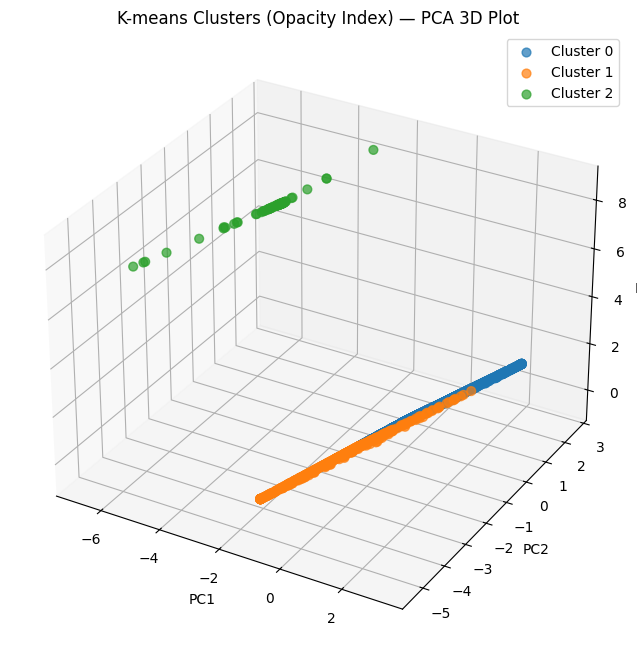

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# drop warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

df_k["PC1"] = X_pca_3d[:, 0]
df_k["PC2"] = X_pca_3d[:, 1]
df_k["PC3"] = X_pca_3d[:, 2]


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(df_k["opacity_cluster"].unique()):
    subset = df_k[df_k["opacity_cluster"] == cluster]
    ax.scatter(
        subset["PC1"], subset["PC2"], subset["PC3"],
        label=f"Cluster {cluster}", s=40, alpha=0.7
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-means Clusters (Opacity Index) — PCA 3D Plot")
ax.legend()

plt.show()
